# Project instructions

We want you to build machine learning models to predict COVID-19 infections from symptoms. It has several applications – for example, triaging patients to be attended by a doctor or nurse, recommending self-isolation through contact tracing apps, etc.

[Zoabi et al.](https://www.nature.com/articles/s41746-020-00372-6) builds a decision tree classifier using the publicly available data reported by the Israeli Ministry of Health. The paper itself discusses the various challenges encountered in deploying such a model. We encourage you to read the paper and learn the challenges and ways to overcome them. We will be using the dataset in this paper.

Below are a list of potential questions and directions that you can explore but you are free and encouraged to be creative and explore other directions to apply your ML skills:

## Exploratory Data Analysis
* Think about possible biases and limitations of this dataset. What are the sources of uncertainty?
* What is the format of feature values?
* What is the statistics of these feature values? How many symptoms are reported or not?
* Which symptoms have a reporting bias, i.e., likely to be reported when the patient is COVID positive?
* How will the symptoms with reporting bias affect the model’s performance?
* Visualization: Draw the bar graph of features grouped by the target class?
* What does the bar graph of the symptoms with reporting bias look like?
* Determine if we have a class imbalance in the dataset? If so, what do you reckon will be the downstream challenges in evaluating the model? How will you overcome those challenges?

## Feature Engineering
* How will you represent the features in numerical format that can be accessible by model?
* Are there any redundancies in your feature representation?

## Models
* Check out various classifiers in sklearn or any other preferred library to build your models

## Evaluate
* Is accuracy the right metric to evaluate the model? Are inaccuracies correctly penalized in the accuracy metric?
* Which dataset should you choose to evaluate the model? Validation or Test?
* What other metric is relevant in our context?

For benchmarking everyone’s results we will stick to ROC-AUC score as a metric.

## Report your result
* With the metric chosen, report your result on the test dataset.
* How will you select the threshold for your model above which model score will be interpreted as a prediction of positive diagnosis.

## Extras
* Dimensionality Reduction for fun: Can you reduce the dimension to just 2 dimensions and check if the inputs corresponding to different classes belong to different clusters? Try using t-SNE or UMAP for that purpose.
* Collaborate with Ensemble: Can you combine other models?

# Work

## Libraries
As always, we'll start by importing the necessary libraries.

In [ ]:
# It's good practice to add comments to explain your code 
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Building the parameter distributions
from scipy.stats import randint

# Analysing performance
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    precision_recall_curve
)


According to scikit-learn documentation, `HistGradientBoostingClassifier` is much faster than GradientBoostingClassifier for big datasets (n_samples >= 10 000).

Using https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_hist_grad_boosting_comparison.html as a starting point:

In [ ]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

And just to define the file as a string:

In [237]:
datafile = 'data/corona_tested_individuals_ver_006.english.csv'

## Data Ingestion

Read in the data file. I'm going to call it `df_006` just because it's file 6; I'll create a copy later.

In [316]:
# Add your code here
df_006 = pd.read_csv(datafile,low_memory=False)

Good practice to check the head and columns:

In [239]:
df_006.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [240]:
df_006.index

RangeIndex(start=0, stop=278848, step=1)

In [319]:
df_006.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB


This function will histogram all columns of a dataframe up:

In [ ]:
def plotfeatures(df) :

    '''Returns m by n set of histographs of feature distrubtions of `df`, where n is ceil(sqrt(df.columns)) and m is sufficient rows to return all columns.'''

    n_features = df.shape[1]

    # Specific example: 10 features; we want 4 columns, which will lead to a 3x4 display
    n_cols = int(np.ceil( np.sqrt( n_features ) )) 
    n_rows = int(np.ceil( n_features / n_cols ))

    fig, ax = plt.subplots(n_rows,n_cols,
                           figsize=(n_cols*3-1,n_rows*3-1))

    # Flatten ax to stop it being 2D, which will make tidying easier later
    ax = ax.flat

    # Still won't help dates, but will at least make other types a bit easier to read
    plt.xticks(fontsize=4)

    for i,col in enumerate(df.columns) :

        # .hist doesn't like boolean data, so let's map it to string instead
        if df[col].dtype == bool :
            ds = df[col].copy().map({True:"True",False:"False"})
        else :
            ds = df[col].copy()

        this_ax = ax[i] # simpler to refer to :)
        ds.hist(ax=this_ax)
        this_ax.tick_params(axis='x',labelsize=6)
        this_ax.tick_params(axis='y',labelsize=4)
        this_ax.set_title(col,fontsize=8)

    # turn off unused charts
    for j in range(n_features,n_rows*n_cols) :
        ax[j].set_visible(False)

    # and present
    fig.tight_layout()
    plt.show()
    

Thus, we have this distribution of values:

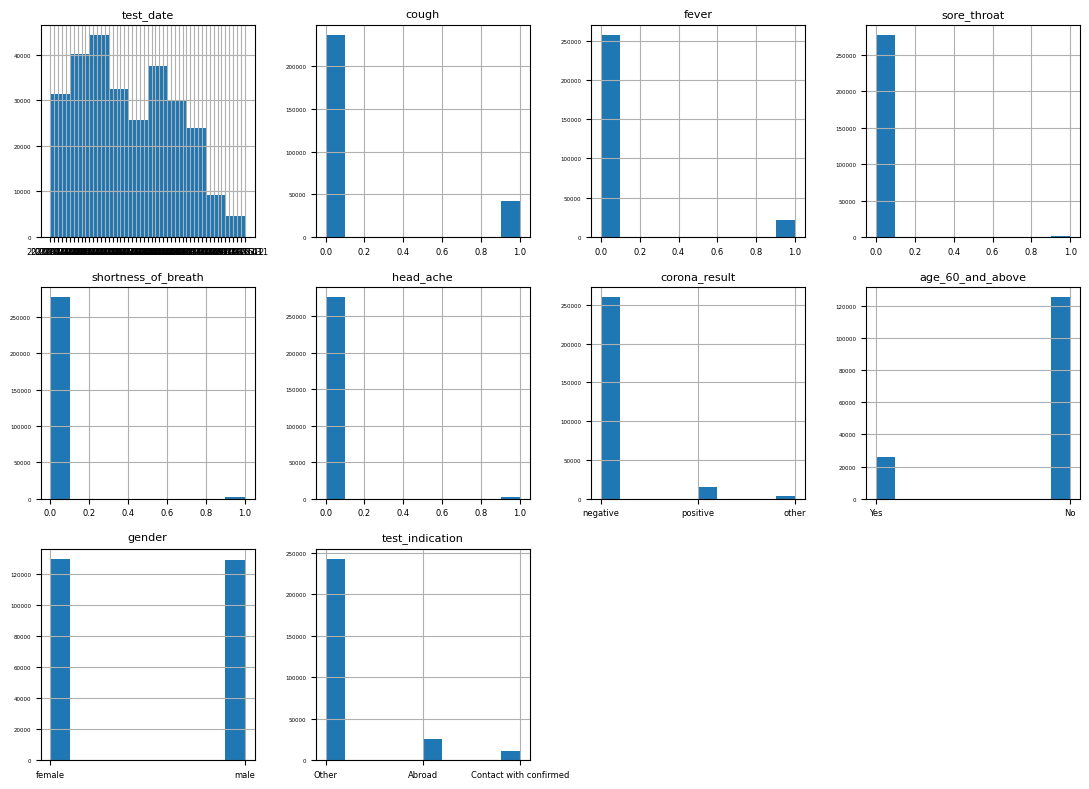

In [242]:
plotfeatures(df_006)

Our target, is `corona_result`; even if we combine "positive" and "other", it's an imbalanced dataset.

Although they're good for general distribution, these histograms won't show null values. Thus:

In [243]:
df_006.isna().sum()

test_date                   0
cough                     252
fever                     252
sore_throat                 1
shortness_of_breath         1
head_ache                   1
corona_result               0
age_60_and_above       127320
gender                  19563
test_indication             0
dtype: int64

## Data Preprocessing

Starting with a fresh copy (and calling it `df`) adjust columns as necessary:

In [ ]:
df = df_006.copy()

# Drop date column since it is not relevant for modeling... yet...
df = df.drop(columns=["test_date"])

# Drop rows with missing target variable
df = df[df["corona_result"] != "other"]

# Set target variable to boolean
df["corona_result"] = df["corona_result"].map({"positive": True, "negative": False})

# To match, only take contact with confirmed
df["test_indication"] = df["test_indication"].map({"Contact with confirmed": True, "Other": False, "Abroad": False}).astype(bool)
# Set others to boolean too
df["gender"] = df["gender"].map({"female": False, "male": True}).astype(bool)
df["age_60_and_above"] = df["age_60_and_above"].map({"Yes": True, "No": False}).astype(bool)


In [245]:
df.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,0.0,0.0,0.0,0.0,0.0,False,True,False,False
1,1.0,0.0,0.0,0.0,0.0,False,True,False,False
2,0.0,1.0,0.0,0.0,0.0,False,True,True,False
3,1.0,0.0,0.0,0.0,0.0,False,True,False,False
4,1.0,0.0,0.0,0.0,0.0,False,True,True,False


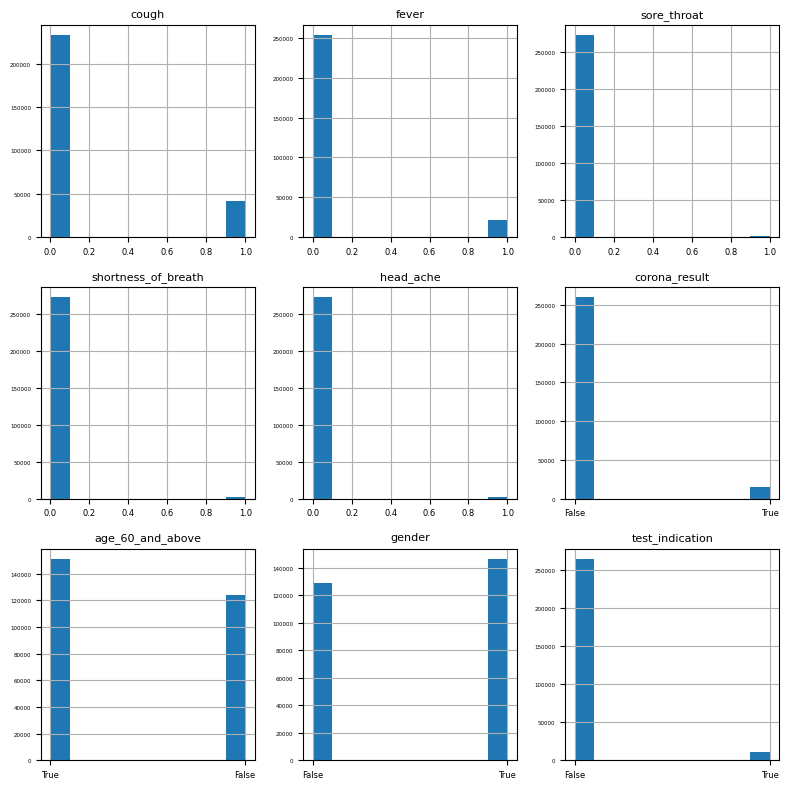

In [246]:
plotfeatures(df)

In [296]:
df.isna().sum()

cough                  252
fever                  252
sore_throat              1
shortness_of_breath      1
head_ache                1
corona_result            0
age_60_and_above         0
gender                   0
test_indication          0
dtype: int64

## Model selection

Working with these features/targets:

In [247]:
# Define X and y
features = ["cough","fever","sore_throat","shortness_of_breath","head_ache","age_60_and_above","gender","test_indication"]
targets = "corona_result"

In [ ]:
# For two lists: 
X = df[features]
y = df[targets]

Since we want the results to be reproducable, let's define a random state to reuse.

In [297]:
rng = np.random.RandomState(42)

I'm working with `HistGradientBoostingClassifier`, which for larger datasets works better than `GradientBoostingClassifier`.

I've also set `class_weight` due to the lack of balance, and turned off `early_stopping`.

In [ ]:
histgbc = HistGradientBoostingClassifier(
    random_state=rng,
    early_stopping=False,
    class_weight="balanced"
    )


Also as a consequence of the imbalance, I'm using `StratifiedKFold` to cross-validate. `KFold` may work, but risks creating disproportionate samples and overweighting the negative results.

In [ ]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=rng)

I'd probably avoid running this. It's the exhaustive version of RandomizedSearchCV - good for getting started, but takes too long in practice!

In [ ]:
# param_grid = {
#     "max_iter": [50, 100, 200, 400, 800],
#     "min_samples_leaf": [1,5,10,15,20,25,30],
#     "max_leaf_nodes" : [10,20,30,40,50,60],
#     "learning_rate" : [0.01,0.02,0.05,0.10]
# }

# gscv = GridSearchCV(
#     estimator=histgbc,
#     param_grid=param_grid,
#     scoring="roc_auc",
#     return_train_score=True,
#     cv=cv,
# ).fit(X, y)

# gscv_result = pd.DataFrame(gscv.cv_results_)
# gscv_result[ gscv_result["rank_test_score"] == 1 ]

I'm going to use `RandomizedSearchCV`, scoring on ROC-AUC, to try and find an optimal parameter distribution.

Remember to tone down the iterations when running on KATE! I haven't tried to find a "maximum" running length it will handle. 25 iterations will take about 10 minutes; 8 might be better for the online portal.

In [ ]:
param_dists = {
    "max_iter": [50, 100, 200, 400, 800],
    "min_samples_leaf": randint(1,30),
    "max_leaf_nodes" : randint(10,60),
    "learning_rate" : [0.01,0.02,0.05,0.10]
}

rscv = RandomizedSearchCV(
    estimator=histgbc,
    param_distributions=param_dists,
    scoring="roc_auc",
    n_iter=25,
    return_train_score=True,
    cv=cv,
    random_state=rng
).fit(X,y)

rscv_result = pd.DataFrame(rscv.cv_results_).sort_values("rank_test_score")
rscv_result.head(10)

Given a tuned model, I can now apply a fit and predict on the "optimal" estimator.

In [ ]:
# TODO list
# I possibly need to switch this to clone instead of just dumping best_estimator onto it
# I'm fitting on the training data - we didn't train/test at the start, so possibly need a fresh out-of-sample cross-validation?
best_model = rscv.best_estimator_
best_model.fit(X,y)
y_prob = best_model.predict_proba(X)
y_pred = best_model.predict(X)

## Analysing initial performance

Just for information, the positive (or non-negative, depending on what we settle on) test rate is:

In [306]:
print(f"Positive Test Rate: {np.mean(df["corona_result"]):.1%}")

Positive Test Rate: 5.4%


And my ROC-AUC score/curve looks like this:

In [307]:
print(f"ROC: {roc_auc_score(y,y_prob[:,1]):.3f}")

ROC: 0.893


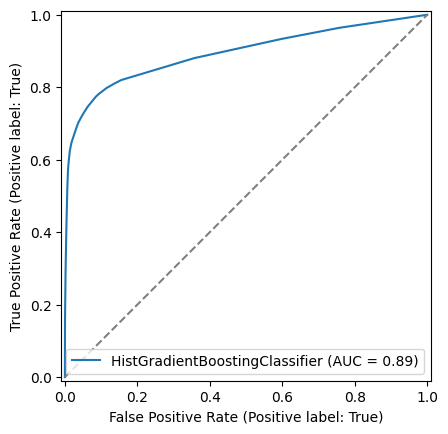

In [ ]:
from sklearn.metrics import RocCurveDisplay

rocaucchart = RocCurveDisplay.from_estimator(best_model,X,y)
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.show()

However, the classification report gives this:

In [308]:
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

       False       0.99      0.91      0.95    260227
        True       0.34      0.77      0.47     14729

    accuracy                           0.91    274956
   macro avg       0.66      0.84      0.71    274956
weighted avg       0.95      0.91      0.92    274956



That recall for the smaller True class is a bit low, so I'm going to see if I can optimise it. If we set a minimum recall target to be 95%:

In [ ]:
def threshold_min_recall(y_true,y_pred
                         ,min_recall = 0.95
                         ,verbose = False) -> float :

    '''Suggests a minimum threshold for a classifer to obtain a specified minimum recall value'''

    precision,recall,thresholds = precision_recall_curve(y_true,y_pred)
    
    mask = recall[:-1] >= min_recall

    best_idx = np.argmax(precision[:-1][mask])

    best_threshold = thresholds[mask][best_idx]
    best_precision = precision[:-1][mask][best_idx]
    best_recall = recall[:-1][mask][best_idx]

    if verbose:
        print(f"Set a threshold for True to be {best_threshold:.3f}")
        print(f"This tunes precision to {best_precision:.3f} and recall to {best_recall:.3f}")
        print(f"It defines a false positive to be about {(1-best_threshold)/best_threshold:.1f} times as important as a false negative")

    return best_threshold

In [368]:
best_threshold = threshold_min_recall(y,y_prob[:,1],verbose=True)

Set a threshold for True to be 0.162
This tunes precision to 0.067 and recall to 0.964
It defines a false positive to be about 6.2 times as important as a false negative


A "revised" classification report, based on that threshold, is:

In [315]:
y_pred_recall = y_prob[:,1] >= best_threshold
print(classification_report(y,y_pred_recall))

              precision    recall  f1-score   support

       False       0.99      0.24      0.39    260227
        True       0.07      0.96      0.13     14729

    accuracy                           0.28    274956
   macro avg       0.53      0.60      0.26    274956
weighted avg       0.94      0.28      0.38    274956



## Going further

`HistGradientBossintClassifier` is often thought to be "over-confident": that is, while it gets the scoring right and ranks well, it doesn't necessarily follow that extreme probailities  are particularly good. This is a general feature of trees, due to their preference to optimise the loss functions locally rather than globally. Therefore, I'll introduce CalibratedClassifierCV to try and make the insights better.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV,calibration_curve

cc_model = CalibratedClassifierCV(
    estimator=best_model,
    method="isotonic",
    cv=4
)

cc_model.fit(X, y)
y_pred_cal = cc_model.predict(X)
y_prob_cal = cc_model.predict_proba(X)


The equivalent ROC curve is identifcal - we're just tuning the classification to make the probabilities mean something different:

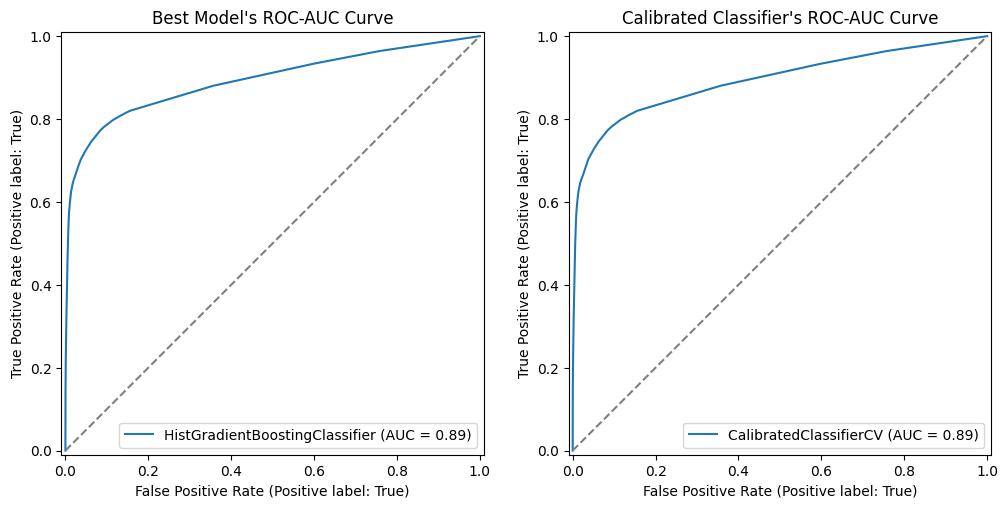

In [356]:
fig,ax = plt.subplots(ncols=2,figsize=(12,6))

RocCurveDisplay.from_estimator(best_model,X,y,ax=ax[0])
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_title("Best Model's ROC-AUC Curve")

RocCurveDisplay.from_estimator(cc_model,X,y,ax=ax[1])
ax[1].plot([0, 1], [0, 1], "--", color="grey")
ax[1].set_title("Calibrated Classifier's ROC-AUC Curve")
plt.show()

But the calibration curve looks different:

In [359]:
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y, y_prob[:, 1], n_bins=10, strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y, y_prob_cal[:, 1], n_bins=20, strategy="quantile"
)

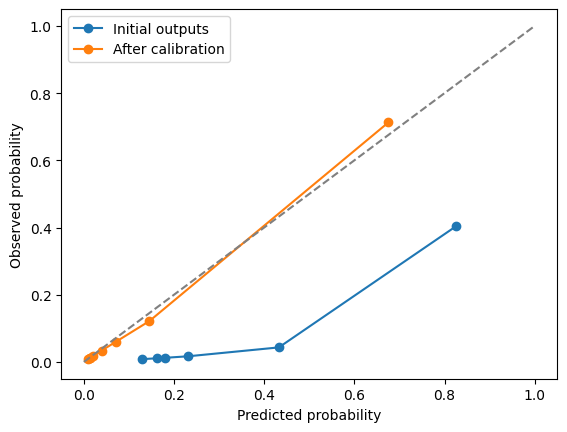

In [361]:
plt.plot(prob_pred_uncal, prob_true_uncal, "o-", label="Initial outputs")
plt.plot(prob_pred_cal, prob_true_cal, "o-", label="After calibration")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.legend()
plt.show()

Further, the threshold choice for optimising recall doesn't change:

In [373]:
cc_threshold = threshold_min_recall(y,y_prob_cal[:,1],verbose=True)


Set a threshold for True to be 0.162
This tunes precision to 0.067 and recall to 0.964
It defines a false positive to be about 6.2 times as important as a false negative


In [372]:
y_pred_recall = y_prob[:,1] >= best_threshold
print(classification_report(y,y_pred_recall))

              precision    recall  f1-score   support

       False       0.99      0.24      0.39    260227
        True       0.07      0.96      0.13     14729

    accuracy                           0.28    274956
   macro avg       0.53      0.60      0.26    274956
weighted avg       0.94      0.28      0.38    274956



In [374]:
y_pred_recall_cal = y_prob_cal[:,1] >= cc_threshold
print(classification_report(y,y_pred_recall))

              precision    recall  f1-score   support

       False       0.99      0.24      0.39    260227
        True       0.07      0.96      0.13     14729

    accuracy                           0.28    274956
   macro avg       0.53      0.60      0.26    274956
weighted avg       0.94      0.28      0.38    274956

